In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import os
EXPERIMENT_LOCATION = 'logs/test2'
all_results = pd.DataFrame()
for folder in os.listdir(EXPERIMENT_LOCATION):
    tmp = pd.read_csv(f"{EXPERIMENT_LOCATION}/{folder}/results.csv").assign(algo = folder)
    all_results = pd.concat([tmp, all_results])

all_results

,Unnamed: 0,timestep,positions,velocities,fuel,rewards,actions,distance_to_target,run,algo
0,0,0,0.005409,0.108179,0.497270,-5.292598,0.545901,4.994591,4,RandomShooting
1,1,1,0.017900,0.249827,0.494378,-5.316802,0.578534,4.982100,4,RandomShooting
2,2,2,0.028960,0.221190,0.492335,-5.138034,0.408649,4.971040,4,RandomShooting
3,3,3,0.062332,0.667453,0.487944,-5.708838,0.878163,4.937668,4,RandomShooting
4,4,4,0.063596,0.025269,0.486936,-4.977026,-0.201549,4.936404,4,RandomShooting
...,...,...,...,...,...,...,...,...,...,...
495,95,95,4.823263,0.005517,0.325066,-0.267215,-0.300796,0.176737,0,CEM
496,96,96,4.824513,0.024990,0.323019,-0.343028,-0.409318,0.175487,0,CEM
497,97,97,4.828505,0.079845,0.321132,-0.314024,-0.377530,0.171495,0,CEM
498,98,98,4.833105,0.091998,0.319060,-0.338611,-0.414386,0.166895,0,CEM


<Axes: xlabel='timestep', ylabel='rewards'>

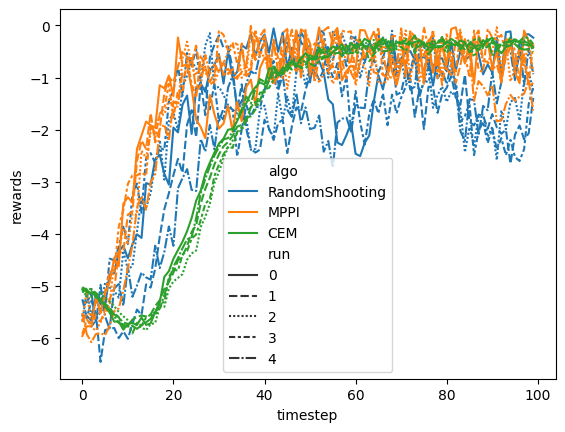

In [16]:
sns.lineplot(
    data=all_results,
    x='timestep',
    y='rewards',
    hue='algo',
    style='run'
)

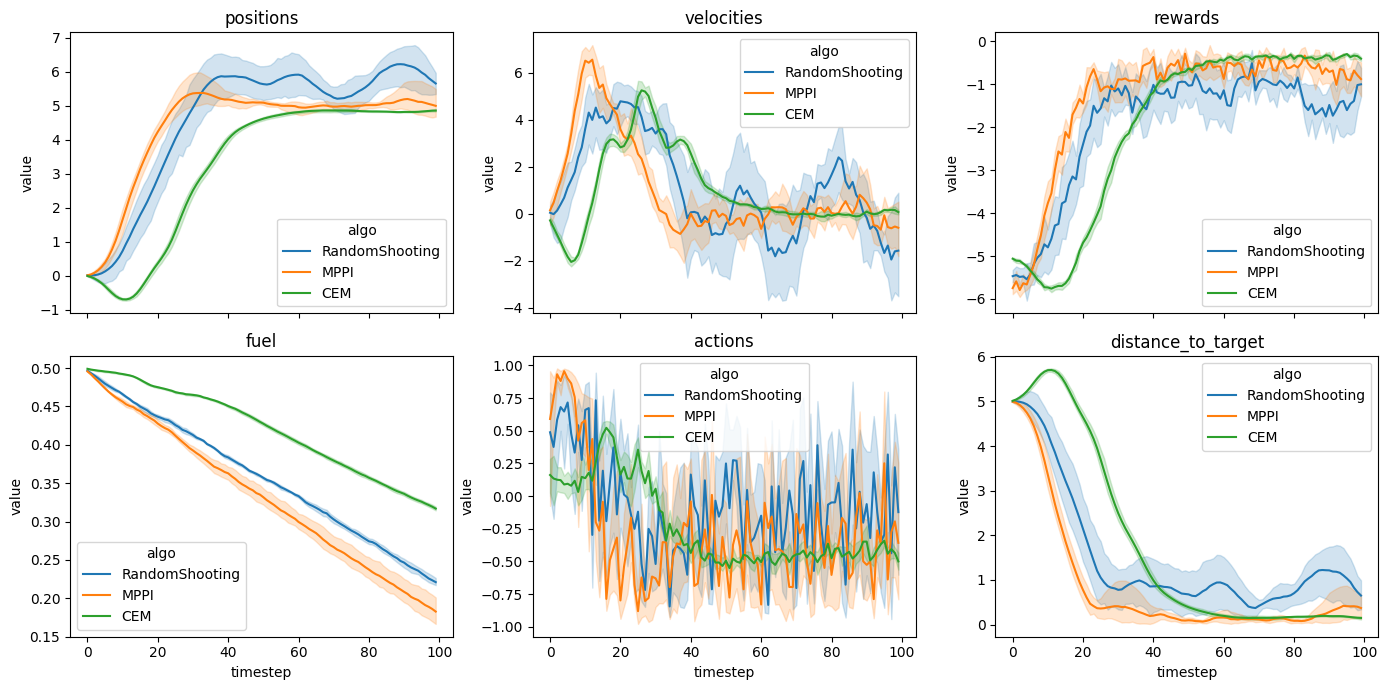

In [17]:
to_plot = all_results.drop('Unnamed: 0', axis=1).melt(id_vars=['algo', 'timestep'])

fig, ax = plt.subplots(2,3, figsize=(14, 7), sharex=True)
ax = ax.flatten()
cols_to_plot =['positions', 'velocities', 'rewards', 'fuel', 'actions', 'distance_to_target'] 
for i, col in enumerate(cols_to_plot):
    sns.lineplot(
        data=to_plot.query('variable == @col'),
        x = 'timestep',
        y = 'value',
        hue='algo',
        ax=ax[i]
    )
    ax[i].set_title(col)
plt.tight_layout()
plt.show();

In [35]:
aggregate_results = all_results.groupby(['algo', 'run']).agg({'rewards': 'mean', 'distance_to_target':'mean'})
# aggregate_results['rewards'].boxplot(x='algo')
# aggregate_results['distance_to_target'].plot(kind='bar', title='distance to target')

<Axes: xlabel='algo', ylabel='distance_to_target'>

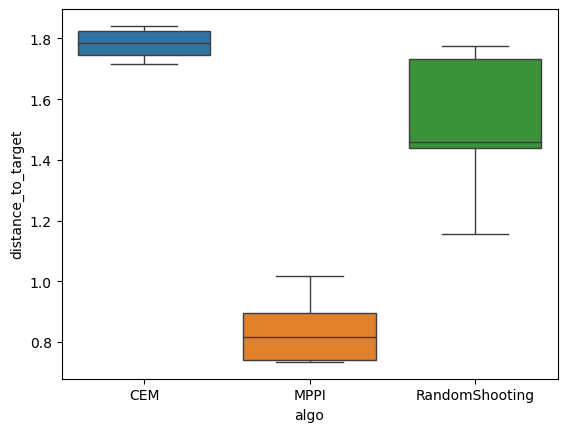

In [39]:
sns.boxplot(
    data=aggregate_results.reset_index(),
    x='algo',
    y='distance_to_target',
    hue='algo'
)

<Axes: xlabel='timestep_min', ylabel='timestep_count'>

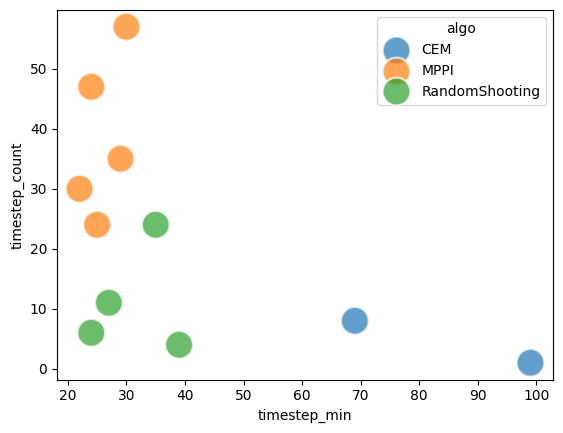

In [20]:
all_results['reach_target'] = (all_results['distance_to_target'] < 0.1)*1
out = (
    all_results
    .groupby(['algo', 'run', 'reach_target'], as_index=False)
    .agg(
        timestep_min=('timestep', 'min'),
        timestep_count=('timestep', 'count')
    )
)


sns.scatterplot(
    data=out.query('reach_target==1'), 
    x='timestep_min', 
    y='timestep_count', 
    hue='algo',
    s = 400,
    alpha = 0.7
)

<Axes: xlabel='timestep', ylabel='distance_to_target'>

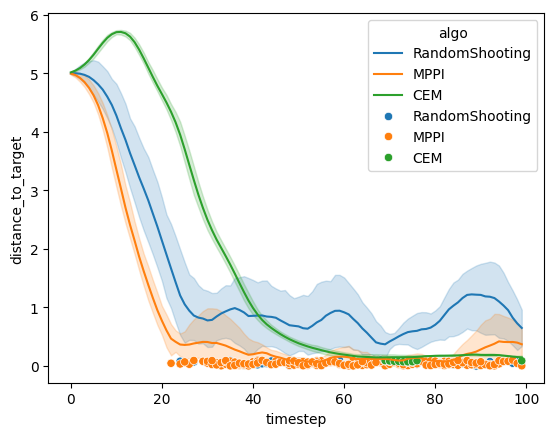

In [21]:
sns.lineplot(
    data=all_results,
    x='timestep',
    y='distance_to_target',
    hue = 'algo'
)

sns.scatterplot(
    data=all_results.query('reach_target==1'),
    x='timestep',
    y='distance_to_target',
    hue='algo'
)